# Concordances

Using polars_corpus to do basic corpus searching

In [3]:
import polars as pl
import polars_corpus as plc
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
bnc = pl.read_parquet("../bnc.parquet")

In [5]:
bnc

tok,c5,pos,mode,text_type,fileid,sentid,hw
str,str,str,str,str,str,str,str
"""ACET""","""NP0""","""SUBST""","""written""","""OTHERPUB""","""A02""","""A02:1""","""acet"""
"""AIDS""","""NN1""","""SUBST""","""written""","""OTHERPUB""","""A02""","""A02:1""","""aids"""
"""CARE""","""NN1-VVB""","""SUBST""","""written""","""OTHERPUB""","""A02""","""A02:1""","""care"""
"""EDUCATION""","""NN1""","""SUBST""","""written""","""OTHERPUB""","""A02""","""A02:1""","""education"""
"""AND""","""CJC""","""CONJ""","""written""","""OTHERPUB""","""A02""","""A02:1""","""and"""
…,…,…,…,…,…,…,…
""".""","""PUN""","""STOP""","""spoken""","""CONVRSN""","""KSV""","""KSV:6013""",null
"""There""","""AV0""","""ADV""","""spoken""","""CONVRSN""","""KSV""","""KSV:6014""","""there"""
"""we""","""PNP""","""PRON""","""spoken""","""CONVRSN""","""KSV""","""KSV:6014""","""we"""


In [23]:
hits = bnc.filter(pl.col("tok").str.to_lowercase().is_in(["very", "really"]),
                  pl.col("c5") == 'AV0')
ratio = (
    hits.group_by("text_type")
    .agg(
        ((pl.col("tok") == "very").sum() / (pl.col("tok") == "really").sum()).alias(
            "ratio"
        )
    )
    .sort(by="ratio")
)
ratio

text_type,ratio
str,f64
"""CONVRSN""",0.704884
"""FICTION""",1.929434
"""OTHERSP""",2.067951
"""NEWS""",2.979175
"""OTHERPUB""",3.073558
"""NONAC""",4.040476
"""UNPUB""",4.05
"""ACPROSE""",5.748962


Text(0, 0.5, 'Text type')

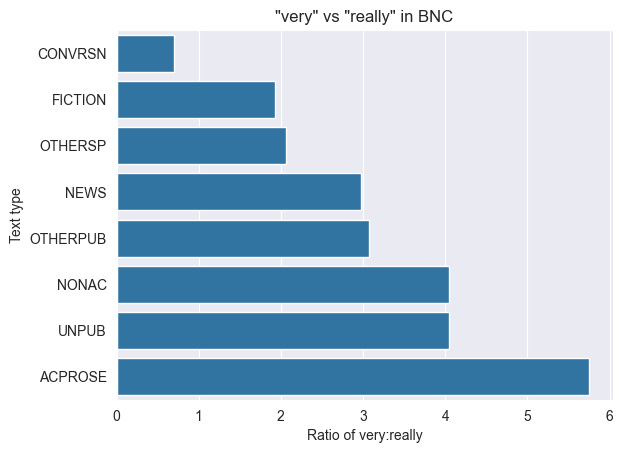

In [24]:
fig, ax = plt.subplots()
sns.barplot(ratio, y="text_type", x="ratio", orient="h", ax=ax)
ax.set_title('"very" vs "really" in BNC')
ax.set_xlabel("Ratio of very:really")
ax.set_ylabel("Text type")

In [22]:
bnc.filter(pl.col('tok')=='really').group_by('c5').len()


c5,len
str,u32
"""UNC""",1
"""AV0""",44325


In [12]:
r = plc.Concordance(bnc, '[tok="very|really"]')

In [13]:
hits = plc.with_spans(bnc, r.spans)  # .filter(pl.col('spans')!='O')

In [14]:
hits.filter(pl.col("spans") != "O")

tok,c5,pos,mode,text_type,fileid,sentid,hw,spans
str,str,str,str,str,str,str,str,str
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:25""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:41""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:60""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:90""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:182""","""very""","""B"""
…,…,…,…,…,…,…,…,…
"""very""","""AV0""","""ADV""","""spoken""","""CONVRSN""","""KSV""","""KSV:5759""","""very""","""B"""
"""very""","""AV0""","""ADV""","""spoken""","""CONVRSN""","""KSV""","""KSV:5771""","""very""","""B"""
"""really""","""AV0""","""ADV""","""spoken""","""CONVRSN""","""KSV""","""KSV:5783""","""really""","""B"""


In [11]:
ratio = (
    hits.group_by("text_type")
    .agg(
        ((pl.col("tok") == "very").sum() / (pl.col("tok") == "really").sum()).alias(
            "ratio"
        )
    )
    .sort(by="ratio")
)
ratio

text_type,ratio
str,f64
"""CONVRSN""",0.71413
"""FICTION""",2.062849
"""OTHERSP""",2.117939
"""NEWS""",3.091058
"""OTHERPUB""",3.228697
"""UNPUB""",4.162037
"""NONAC""",4.347436
"""ACPROSE""",6.33641
